**Exercise 1 - Parameter Exploration in Felzenszwalb Segmentation**

Segment hogwarts.jpeg three times using felzenszwalb with different parameter settings.
Use the same image and plot the three segmentation maps side by side using mark_boundaries.

Parameters to vary:
* scale=50, sigma=0.5, min_size=20
* scale=200, sigma=0.5, min_size=50
* scale=200, sigma=1.0, min_size=100

Output: one figure with three subplots as shown below:

<img src="E1Output.png"/>

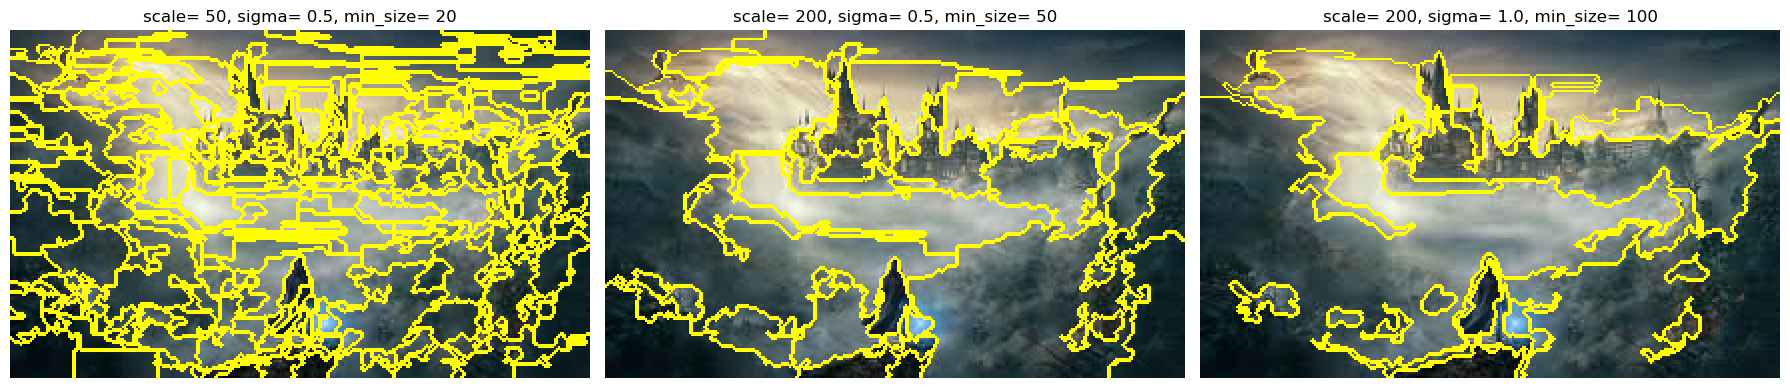

In [9]:
import numpy as np
from skimage import io, segmentation, transform, img_as_float
import matplotlib.pyplot as plt

# Crearemos una función para poder aplicar la segmentación de Felzenszwalb y poder mostrar el resultado
def explore_felzenszwalb(image_path, params_list):
    # Leemos la imagen
    image = io.imread(image_path)

    # Convertimos la imagen a float, ya que algunas funciones requieren este formato. 
    image_float = img_as_float(image)

    # Haremos uso de un for para poder dibujar las imágenes 
    fig, axes = plt.subplots(1, len(params_list), figsize=(18, 6))

    for i, params in enumerate(params_list):
        # Para cada lista de parámetros dada, aplicaremos la segmentación de Felzenszwalb 
        segments = segmentation.felzenszwalb(image_float, **params)

        # Mostramos el resultado
        axes[i].imshow(segmentation.mark_boundaries(image_float, segments))
        axes[i].set_title(f"scale= {params['scale']}, sigma= {params['sigma']}, min_size= {params['min_size']}")
        axes[i].axis('off')

    plt.tight_layout()
    plt.show()

# Combinaciones de parámetros que se piden en el enunciado para explorar. 
param_combinations = [
    {'scale': 50, 'sigma': 0.5, 'min_size': 20},
    {'scale': 200, 'sigma': 0.5, 'min_size': 50},
    {'scale': 200, 'sigma': 1.0, 'min_size': 100}
]

# Llamamos a la función que hemos creado para mostrar el resultado de hacer la segmentación de Felzenszwalb para cada lista de parámetros indicada
explore_felzenszwalb('hogwarts.jpeg', param_combinations)